In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, ConcatDataset
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Image transformation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load MRI dataset
mri_dataset = datasets.ImageFolder(
    root='/kaggle/input/brain-tumor-multimodal-image-ct-and-mri/Dataset/Brain Tumor MRI images',
    transform=transform)

# Load CT dataset
ct_dataset = datasets.ImageFolder(
    root='/kaggle/input/brain-tumor-multimodal-image-ct-and-mri/Dataset/Brain Tumor CT scan Images',
    transform=transform)

# Load Alzheimer dataset
alz_dataset = datasets.ImageFolder(
    root='/kaggle/input/alzhimer-ds/Alzhimer DS - Copy/AugmentedAlzheimerDataset',
    transform=transform)


In [4]:
total_dataset = ConcatDataset([mri_dataset, ct_dataset, alz_dataset])
train_size = int(0.8 * len(total_dataset))
test_size = len(total_dataset) - train_size
train_dataset, test_dataset = random_split(total_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [5]:
class CNNModel(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, 1, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(),
            nn.Conv2d(128, 256, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(256, 512, 3, 1, 1), nn.ReLU(),
            nn.Conv2d(512, 1024, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.MaxPool2d(4, 4),
            nn.Flatten(),
            nn.Linear(7*7*1024, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 3)
        )

    def forward(self, x):
        return self.layer_stack(x)

In [6]:
model = CNNModel(in_channels=3, num_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 50
all_labels = []
all_predictions = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()


100%|██████████| 643/643 [06:45<00:00,  1.58it/s]


In [7]:
model.eval()
correct, total = 0, 0
with torch.inference_mode():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {100 * correct / total:.2f}%")


Epoch [50/50], Loss: 0.0044, Accuracy: 99.09%


ValueError: The number of FixedLocator locations (2), usually from a call to set_ticks, does not match the number of labels (4).

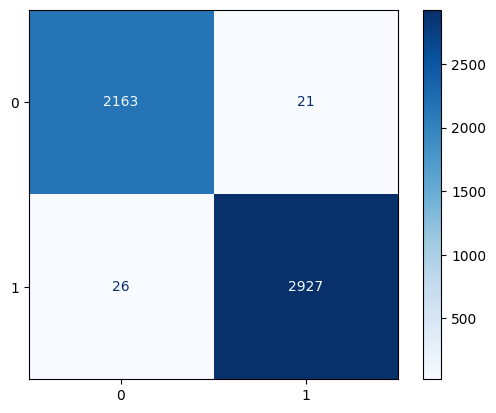

In [10]:
cm = confusion_matrix(all_labels, all_predictions)

display_labels = ['ModerateDemented', 'non demented', 'Tumor', 'Health']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [11]:
# cm = confusion_matrix(all_labels, all_predictions)

# # Define the class labels (adjust as per your actual 4 classes)
# class_names = ['MRI_Tumor', 'CT_Tumor', 'CT_Normal', 'Alzheimer']

# # Create a DataFrame for better readability
# cm_df = pd.DataFrame(cm, index=class_names[:cm.shape[0]], columns=class_names[:cm.shape[1]])

# print("Confusion Matrix Table:")
# print(cm_df)


Confusion Matrix Table:
           MRI_Tumor  CT_Tumor
MRI_Tumor       2186         9
CT_Tumor          49      2893


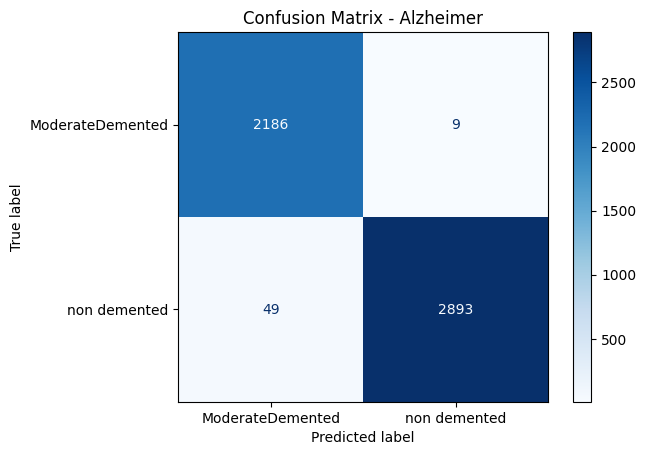

In [14]:
subset1_labels = [0, 1]
subset1_display = ['ModerateDemented', 'non demented']

cm1 = confusion_matrix(
    [label for label in all_labels if label in subset1_labels],
    [pred for label, pred in zip(all_labels, all_predictions) if label in subset1_labels],
    labels=subset1_labels
)

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=subset1_display)
disp1.plot(cmap='Blues')
plt.title("Confusion Matrix - Alzheimer")
plt.show()

In [ ]:
# cm = confusion_matrix(all_labels, all_predictions)
# labels = list(mri_dataset.classes) + list(ct_dataset.classes) + list(alz_dataset.classes)
# display_labels = sorted(set(labels))
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
# disp.plot()
# plt.title("Confusion Matrix")
# plt.show()

In [8]:
torch.save(model, 'combined_model.pth')
model = torch.load('combined_model.pth').to(device)

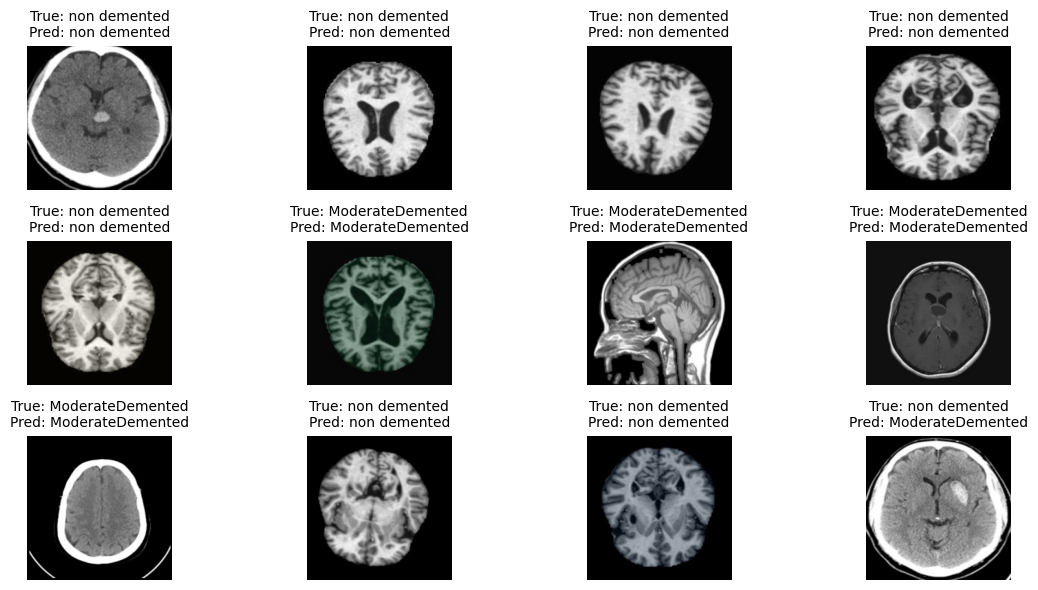

In [11]:
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
model.eval()
logits = model(images)
_, preds = torch.max(logits, 1)

true_labels = [display_labels[label.item()] for label in labels]
predicted_labels = [display_labels[pred.item()] for pred in preds]

plt.figure(figsize=(12, 6))
for i in range(min(12, len(images))):
    plt.subplot(3, 4, i + 1)
    img = images[i].cpu().permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(f"True: {true_labels[i]}\nPred: {predicted_labels[i]}", fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [12]:
from PIL import Image

def classify_single_image(image_path, model, transform, class_labels):
    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension

    # Set model to evaluation mode
    model.eval()
    with torch.inference_mode():
        output = model(image_tensor)
        _, predicted = torch.max(output, 1)
    
    predicted_class = class_labels[predicted.item()]
    plt.imshow(image)
    plt.title(f"Predicted: {predicted_class}", fontsize=14)
    plt.axis('off')
    plt.show()
    return predicted_class


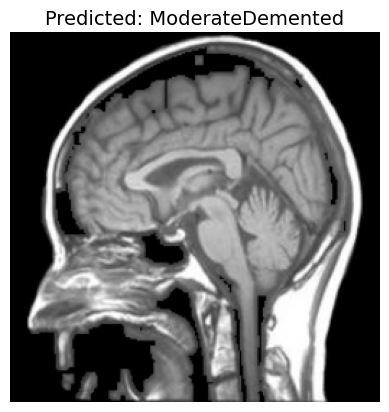

Prediction: ModerateDemented


In [13]:
image_path = "/kaggle/input/brain-tumor-multimodal-image-ct-and-mri/Dataset/Brain Tumor MRI images/Healthy/mri_healthy (1007).jpg"
predicted = classify_single_image(image_path, model, transform, display_labels)
print("Prediction:", predicted)